In [3]:
# Fund Performance Analytics
# Computes performance metrics for all mutual fund schemes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')

# Load datasets
fund_master = pd.read_csv('../data/processed/fund_master_cleaned.csv')
nav_history = pd.read_csv('../data/processed/nav_history_cleaned.csv')
scheme_performance = pd.read_csv('../data/processed/scheme_performance_cleaned.csv')
benchmark_indices = pd.read_csv('../data/processed/benchmark_indices_cleaned.csv')

# Convert date columns
nav_history['date'] = pd.to_datetime(nav_history['date'], format='%Y-%m-%d')
benchmark_indices['date'] = pd.to_datetime(benchmark_indices['date'], format='%Y-%m-%d')

# Create reports directory
os.makedirs('reports', exist_ok=True)

print("Data loaded successfully!")

Data loaded successfully!


In [4]:
# Compute Daily Returns and Annualised Returns

# Sort by date
nav_history = nav_history.sort_values(['amfi_code', 'date'])

# Calculate daily returns for each scheme
nav_history['daily_return'] = nav_history.groupby('amfi_code')['nav'].pct_change()

# Remove first row of each group (NaN)
nav_history = nav_history.dropna(subset=['daily_return'])

# Calculate Annualised Return
annualised_returns = []

for amfi_code in nav_history['amfi_code'].unique():
    scheme_data = nav_history[nav_history['amfi_code'] == amfi_code].sort_values('date')
    scheme_name = fund_master[fund_master['amfi_code'] == amfi_code]['scheme_name'].iloc[0]
    
    n = len(scheme_data)
    if n > 0:
        # Annualised Return = (1 + daily_return).prod()^(252/n) − 1
        annualised_return = (1 + scheme_data['daily_return']).prod() ** (252/n) - 1
    else:
        annualised_return = np.nan
    
    annualised_returns.append({
        'amfi_code': amfi_code,
        'scheme_name': scheme_name,
        'annualised_return': annualised_return
    })

annualised_df = pd.DataFrame(annualised_returns)

# Merge with daily returns
returns_computed = nav_history.merge(annualised_df, on=['amfi_code'], how='left')

print(f"Daily returns computed for {nav_history['amfi_code'].nunique()} schemes")
print(f"Total rows: {len(nav_history)}")
print("\nSample with annualised returns:")
returns_computed[['amfi_code', 'date', 'nav', 'daily_return', 'annualised_return']].head()

Daily returns computed for 40 schemes
Total rows: 64280

Sample with annualised returns:


,amfi_code,date,nav,daily_return,annualised_return
0,100016,2022-01-04,515.0971,-0.010306,0.018121
1,100016,2022-01-05,521.7239,0.012865,0.018121
2,100016,2022-01-06,515.7880,-0.011377,0.018121
3,100016,2022-01-07,515.1639,-0.001210,0.018121
4,100016,2022-01-08,515.1639,0.000000,0.018121


In [5]:
# Export returns_computed.csv
returns_computed.to_csv('../data/analytics/returns_computed.csv', index=False)

Number of extreme returns (>20% or <-20%): 0
Percentage of outliers: 0.00%


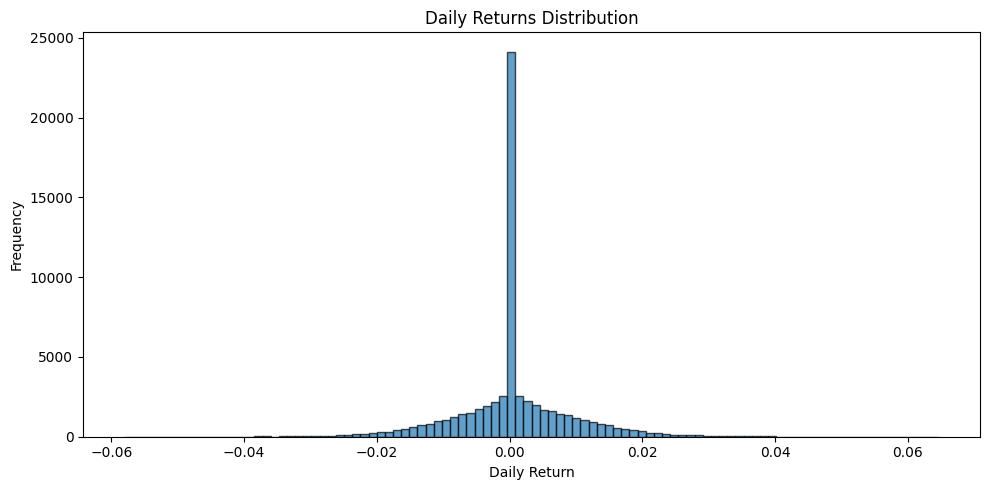


Daily Return Summary Statistics:
count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64


In [6]:
# Validate Daily Return Distribution

# Check for outliers (returns > 20% or < -20%)
outliers = nav_history[abs(nav_history['daily_return']) > 0.20]
print(f"Number of extreme returns (>20% or <-20%): {len(outliers)}")
print(f"Percentage of outliers: {len(outliers)/len(nav_history)*100:.2f}%")

# Plot distribution
plt.figure(figsize=(10, 5))
plt.hist(nav_history['daily_return'], bins=100, edgecolor='black', alpha=0.7)
plt.title('Daily Returns Distribution')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('../reports/figures/daily_return_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nDaily Return Summary Statistics:")
print(nav_history['daily_return'].describe())

In [7]:
# Compute CAGR (1-year, 3-year, 5-year)

# Get latest and historical dates
latest_date = nav_history['date'].max()
cagr_periods = {
    '1yr': latest_date - pd.DateOffset(years=1),
    '3yr': latest_date - pd.DateOffset(years=3),
    '5yr': latest_date - pd.DateOffset(years=5)
}

# Function to calculate CAGR
def calculate_cagr(start_nav, end_nav, years):
    if start_nav <= 0 or end_nav <= 0:
        return np.nan
    return (end_nav / start_nav) ** (1/years) - 1

# Calculate CAGR for each scheme
cagr_results = []

for amfi_code in nav_history['amfi_code'].unique():
    scheme_nav = nav_history[nav_history['amfi_code'] == amfi_code].sort_values('date')
    scheme_name = fund_master[fund_master['amfi_code'] == amfi_code]['scheme_name'].iloc[0]
    fund_house = fund_master[fund_master['amfi_code'] == amfi_code]['fund_house'].iloc[0]
    category = fund_master[fund_master['amfi_code'] == amfi_code]['category'].iloc[0]
    
    latest_nav = scheme_nav.iloc[-1]['nav']
    
    cagr_row = {
        'amfi_code': amfi_code, 
        'scheme_name': scheme_name,
        'fund_house': fund_house,
        'category': category
    }
    
    for period, start_date in cagr_periods.items():
        start_nav_row = scheme_nav[scheme_nav['date'] >= start_date]
        if not start_nav_row.empty:
            start_nav = start_nav_row.iloc[0]['nav']
            years = int(period.replace('yr', ''))
            cagr = calculate_cagr(start_nav, latest_nav, years)
            cagr_row[f'cagr_{period}'] = cagr
        else:
            cagr_row[f'cagr_{period}'] = np.nan
    
    cagr_results.append(cagr_row)

cagr_report = pd.DataFrame(cagr_results)
print("CAGR computed for all schemes")
cagr_report.head()

CAGR computed for all schemes


,amfi_code,scheme_name,fund_house,category,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,-0.022243,0.012926,0.025290
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,0.037050,0.039164,0.039866
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,0.532324,0.324425,0.264128
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,0.479241,0.289677,0.204150
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,-0.239860,-0.041524,0.071873


In [8]:
# Export cagr_report.csv
cagr_report.to_csv('../data/analytics/cagr_report.csv', index=False)

In [9]:
# Build Comparison Table for All Funds

# Merge all performance metrics
comparison_table = scheme_performance.merge(
    cagr_report[['amfi_code', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr']], 
    on='amfi_code', 
    how='left'
)

# Select relevant columns
comparison_table = comparison_table[[
    'amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
    'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
    'cagr_1yr', 'cagr_3yr', 'cagr_5yr',
    'sharpe_ratio', 'alpha', 'beta', 'std_dev_ann_pct',
    'expense_ratio_pct', 'aum_crore'
]]

# Sort by 3-year return
comparison_table = comparison_table.sort_values('return_3yr_pct', ascending=False)

print(f"Comparison table built for {len(comparison_table)} funds")
comparison_table.head(10)

Comparison table built for 40 funds


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,beta,std_dev_ann_pct,expense_ratio_pct,aum_crore
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,0.827761,0.266699,0.284139,0.94,1.23,0.89,25.0,1.43,19259
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,0.139478,-0.013374,0.021910,0.93,1.13,1.04,25.0,0.72,36061
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,-0.239860,-0.041524,0.071873,0.90,1.84,0.97,25.0,1.53,41613
27,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Small Cap,Regular,21.97,20.98,22.62,-0.427976,-0.117058,0.009617,0.84,0.51,1.00,25.0,1.38,21545
17,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Small Cap,Regular,21.30,20.15,21.88,0.158112,0.080079,0.143582,0.81,0.80,1.03,25.0,1.53,43630
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,0.651387,0.270004,0.281877,0.80,0.69,0.98,25.0,1.52,35124
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,0.225020,0.077560,0.055107,0.96,1.91,1.00,19.0,1.56,47469
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,0.296047,0.317775,0.288939,0.95,0.89,1.00,19.0,1.36,979
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,Regular,14.12,17.16,19.00,0.214812,0.268700,0.255997,0.90,1.02,0.98,19.0,1.61,37835
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,0.532324,0.324425,0.264128,0.87,0.95,0.91,19.0,1.38,23185


In [10]:
# ## 5. Compute Sharpe Ratio

# Risk-free rate (6.5% annual)
risk_free_rate = 0.065
risk_free_daily = risk_free_rate / 252

# Function to calculate Sharpe Ratio
def calculate_sharpe_ratio(daily_returns, risk_free_daily):
    excess_returns = daily_returns - risk_free_daily
    return np.sqrt(252) * excess_returns.mean() / excess_returns.std()

# Compute Sharpe ratio for each scheme
sharpe_results = []

for amfi_code in nav_history['amfi_code'].unique():
    scheme_data = nav_history[nav_history['amfi_code'] == amfi_code]
    scheme_returns = scheme_data['daily_return']
    scheme_name = fund_master[fund_master['amfi_code'] == amfi_code]['scheme_name'].iloc[0]
    
    if len(scheme_returns) > 0 and scheme_returns.std() > 0:
        sharpe = calculate_sharpe_ratio(scheme_returns, risk_free_daily)
        sharpe_results.append({
            'amfi_code': amfi_code, 
            'scheme_name': scheme_name,
            'sharpe_ratio': sharpe
        })
    else:
        sharpe_results.append({
            'amfi_code': amfi_code, 
            'scheme_name': scheme_name,
            'sharpe_ratio': np.nan
        })

sharpe_values = pd.DataFrame(sharpe_results)
print("Sharpe ratios computed")
sharpe_values.head()

Sharpe ratios computed


,amfi_code,scheme_name,sharpe_ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.321019
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-1.039941
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.808268
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.717409
4,101207,ABSL Small Cap Fund - Regular - Growth,0.052618


In [11]:
# Export sharpe_values.csv

sharpe_values.to_csv('../data/analytics/sharpe_values.csv', index=False)

In [12]:
# 6. Compute Sortino Ratio

# Function to calculate Sortino Ratio
def calculate_sortino_ratio(daily_returns, risk_free_daily):
    excess_returns = daily_returns - risk_free_daily
    downside_returns = excess_returns[excess_returns < 0]
    
    if len(downside_returns) == 0:
        return np.nan
    
    downside_deviation = downside_returns.std()
    if downside_deviation == 0:
        return np.nan
    
    return np.sqrt(252) * excess_returns.mean() / downside_deviation

# Compute Sortino ratio for each scheme
sortino_results = []

for amfi_code in nav_history['amfi_code'].unique():
    scheme_data = nav_history[nav_history['amfi_code'] == amfi_code]
    scheme_returns = scheme_data['daily_return']
    scheme_name = fund_master[fund_master['amfi_code'] == amfi_code]['scheme_name'].iloc[0]
    
    if len(scheme_returns) > 0:
        sortino = calculate_sortino_ratio(scheme_returns, risk_free_daily)
        sortino_results.append({
            'amfi_code': amfi_code,
            'scheme_name': scheme_name,
            'sortino_ratio': sortino
        })
    else:
        sortino_results.append({
            'amfi_code': amfi_code,
            'scheme_name': scheme_name,
            'sortino_ratio': np.nan
        })

sortino_values = pd.DataFrame(sortino_results)
print("Sortino ratios computed")
sortino_values.head()

Sortino ratios computed


,amfi_code,scheme_name,sortino_ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.471136
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-1.527609
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.184424
3,101206,ABSL Frontline Equity Fund - Regular - Growth,1.078795
4,101207,ABSL Small Cap Fund - Regular - Growth,0.076123


In [13]:
# Export sortino_values.csv

sortino_values.to_csv('../data/analytics/sortino_values.csv', index=False)

sortino_values.csv saved to reports/


In [14]:
# Compute Alpha and Beta

# Nifty 100 benchmark returns
nifty100 = benchmark_indices[benchmark_indices['index_name'] == 'NIFTY100'].copy()
nifty100 = nifty100.sort_values('date')
nifty100['benchmark_return'] = nifty100['close_value'].pct_change()

# Merge fund returns with benchmark returns
fund_returns_pivot = nav_history.pivot(index='date', columns='amfi_code', values='daily_return')

# Align dates
fund_returns_pivot = fund_returns_pivot.sort_index()
nifty100_aligned = nifty100.set_index('date')['benchmark_return']

# Find common dates
common_dates = fund_returns_pivot.index.intersection(nifty100_aligned.index)
fund_returns_aligned = fund_returns_pivot.loc[common_dates]
benchmark_returns_aligned = nifty100_aligned.loc[common_dates]

# Compute Alpha and Beta for each scheme
alpha_beta_results = []

for amfi_code in fund_returns_aligned.columns:
    fund_returns = fund_returns_aligned[amfi_code]
    scheme_name = fund_master[fund_master['amfi_code'] == amfi_code]['scheme_name'].iloc[0]
    
    # Remove NaN values
    mask = ~(fund_returns.isna() | benchmark_returns_aligned.isna())
    
    if sum(mask) > 30:  # At least 30 observations
        x = benchmark_returns_aligned[mask]
        y = fund_returns[mask]
        
        # Linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        
        # Annualize
        beta = slope
        alpha_annual = intercept * 252  # Annualized alpha
        
        alpha_beta_results.append({
            'amfi_code': amfi_code,
            'scheme_name': scheme_name,
            'beta': beta,
            'alpha': alpha_annual,
            'r_squared': r_value ** 2,
            'observations': sum(mask)
        })
    else:
        alpha_beta_results.append({
            'amfi_code': amfi_code,
            'scheme_name': scheme_name,
            'beta': np.nan,
            'alpha': np.nan,
            'r_squared': np.nan,
            'observations': sum(mask)
        })

alpha_beta_df = pd.DataFrame(alpha_beta_results)
print("Alpha and Beta computed")
alpha_beta_df.head()

Alpha and Beta computed


,amfi_code,scheme_name,beta,alpha,r_squared,observations
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.058268,0.037476,0.002665,1149
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.001158,0.042818,0.000015,1149
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.005104,0.271954,0.000012,1149
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.021086,0.213998,0.000348,1149
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.065289,0.108971,0.001064,1149


In [15]:
# Export alpha_beta.csv
alpha_beta_df.to_csv('../data/analytics/new/alpha_beta.csv', index=False)

In [16]:
# Compute Maximum Drawdown and Identify Worst Period
def calculate_max_drawdown(nav_series, dates):
    """Calculate maximum drawdown with full period identification"""
    if len(nav_series) < 2:
        return np.nan, None, None, None
    
    # Calculate running maximum
    running_max = nav_series.expanding().max()
    
    # Calculate drawdown
    drawdown = (nav_series - running_max) / running_max
    
    # Maximum drawdown (most negative)
    max_drawdown = drawdown.min()
    trough_date = dates[drawdown.idxmin()]
    
    # Find peak date (when running max was highest before trough)
    peak_idx = drawdown.index.get_loc(drawdown.idxmin())
    peak_series = running_max[:peak_idx+1]
    peak_date = dates[peak_series.idxmax()]
    
    # Find end date (when drawdown recovers back to zero or reaches end)
    recovery_date = None
    for i in range(peak_idx, len(drawdown)):
        if drawdown.iloc[i] >= 0:
            recovery_date = dates.iloc[i]
            break
    
    return max_drawdown, peak_date, trough_date, recovery_date

# Compute max drawdown for each scheme
drawdown_results = []

for amfi_code in nav_history['amfi_code'].unique():
    scheme_data = nav_history[nav_history['amfi_code'] == amfi_code].sort_values('date')
    scheme_name = fund_master[fund_master['amfi_code'] == amfi_code]['scheme_name'].iloc[0]
    
    if len(scheme_data) > 1:
        max_dd, peak_date, trough_date, recovery_date = calculate_max_drawdown(
            scheme_data['nav'], 
            scheme_data['date']
        )
        
        drawdown_results.append({
            'amfi_code': amfi_code,
            'scheme_name': scheme_name,
            'max_drawdown': max_dd,
            'peak_date': peak_date,
            'trough_date': trough_date,
            'recovery_date': recovery_date
        })

max_drawdown = pd.DataFrame(drawdown_results)
print("Maximum drawdown computed with worst periods identified")
max_drawdown.head()

Maximum drawdown computed with worst periods identified


,amfi_code,scheme_name,max_drawdown,peak_date,trough_date,recovery_date
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.247344,2022-03-30,2022-09-15,2023-03-14
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.043083,2023-05-23,2023-07-28,2024-01-30
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.162172,2022-03-11,2022-05-12,2022-07-27
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.112916,2023-04-24,2023-07-05,2023-09-28
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.354469,2024-11-21,2026-05-11,NaT


In [17]:
# Export max_drawdown.csv
max_drawdown.to_csv('../data/analytics/max_drawdown.csv', index=False)

In [18]:
# 9. Build Fund Scorecard (0-100)

# Merge all metrics
scorecard = comparison_table.merge(
    sharpe_values, on=['amfi_code', 'scheme_name'], how='left'
).merge(
    sortino_values, on=['amfi_code', 'scheme_name'], how='left'
).merge(
    alpha_beta_df[['amfi_code', 'alpha']], on='amfi_code', how='left'
).merge(
    max_drawdown[['amfi_code', 'max_drawdown']], on='amfi_code', how='left'
)

# Calculate ranks (higher is better except for expense ratio and max drawdown)
scorecard['rank_3yr_return'] = scorecard['return_3yr_pct'].rank(ascending=False, pct=True)
scorecard['rank_sharpe'] = scorecard['sharpe_ratio_x'].rank(ascending=False, pct=True)
scorecard['rank_alpha'] = scorecard['alpha_x'].rank(ascending=False, pct=True)
scorecard['rank_expense'] = scorecard['expense_ratio_pct'].rank(ascending=True, pct=True)  # Lower is better
scorecard['rank_drawdown'] = scorecard['max_drawdown'].rank(ascending=True, pct=True)  # Less negative is better

# Calculate score (0-100)
scorecard['score'] = (
    scorecard['rank_3yr_return'] * 0.30 +
    scorecard['rank_sharpe'] * 0.25 +
    scorecard['rank_alpha'] * 0.20 +
    scorecard['rank_expense'] * 0.15 +
    scorecard['rank_drawdown'] * 0.10
) * 100

# Sort by score
fund_scorecard = scorecard.sort_values('score', ascending=False)

print("Fund Scorecard built!")
fund_scorecard[['scheme_name', 'fund_house', 'category', 'score', 'return_3yr_pct', 'sharpe_ratio_x']].head(10)

Fund Scorecard built!


,scheme_name,fund_house,category,score,return_3yr_pct,sharpe_ratio_x
22,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,79.5000,13.58,0.80
32,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Prudential MF,Large Cap,78.4375,11.54,0.82
30,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Large Cap,72.1875,11.84,0.85
25,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,69.5000,12.36,0.88
29,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,Index,69.4375,12.10,0.93
27,Kotak Bluechip Fund - Regular - Growth,Kotak Mahindra MF,Large Cap,66.0000,12.25,0.87
33,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,61.1875,11.30,0.81
5,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,57.5000,20.08,0.80
38,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,Gilt,56.8750,5.31,1.33
39,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,56.0000,5.14,5.14


In [19]:
# Export fund_scorecard.csv
fund_scorecard.to_csv('../data/analytics/fund_scorecard.csv', index=False)

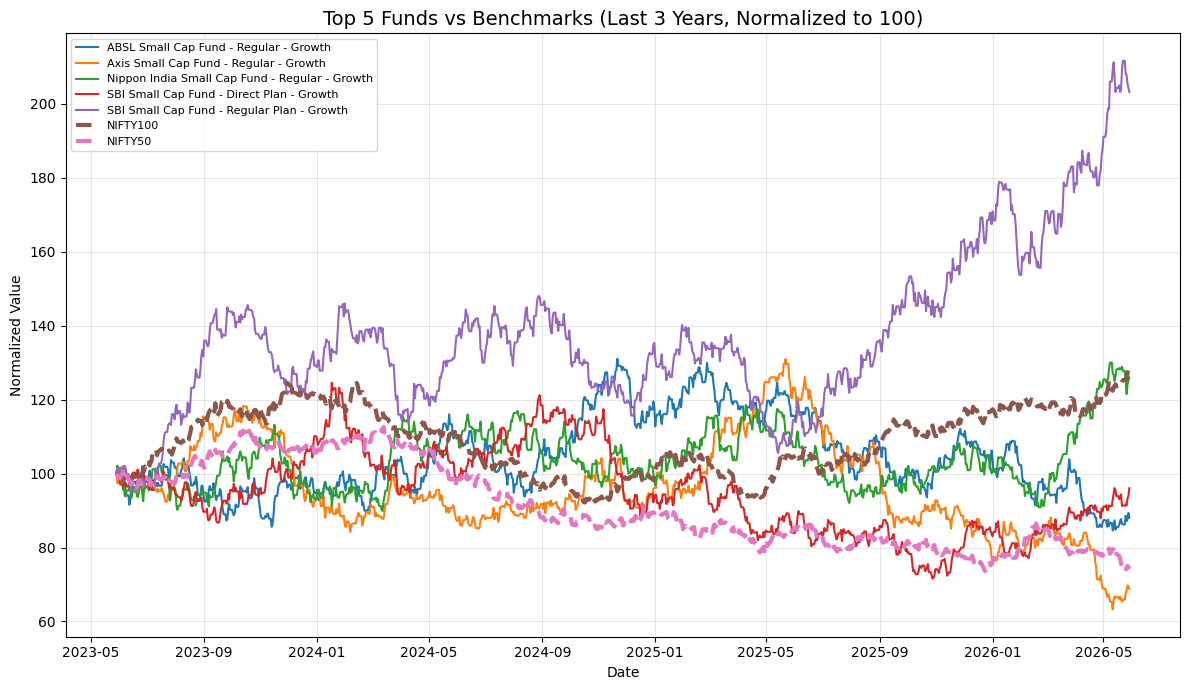

In [20]:
# 10. Benchmark Comparison - Top 5 Funds vs Nifty 50 and Nifty 100 (Last 3 Years)

# Get top 5 funds by 3-year return
top_5_funds = comparison_table.nlargest(5, 'return_3yr_pct')['amfi_code'].tolist()

# Get NAV data for top 5 funds
top_5_nav = nav_history[nav_history['amfi_code'].isin(top_5_funds)]
top_5_nav = top_5_nav.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code')

# Filter last 3 years
three_years_ago = nav_history['date'].max() - pd.DateOffset(years=3)
top_5_nav = top_5_nav[top_5_nav['date'] >= three_years_ago]

# Get benchmark data (Nifty 50 and Nifty 100)
benchmark_data = benchmark_indices[benchmark_indices['index_name'].isin(['NIFTY50', 'NIFTY100'])]
benchmark_data = benchmark_data[benchmark_data['date'] >= three_years_ago]

# Normalize to 100 at start
def normalize_to_100(data):
    return (data / data.iloc[0]) * 100

# Pivot data
nav_pivot = top_5_nav.pivot(index='date', columns='scheme_name', values='nav')
nav_pivot = nav_pivot.apply(normalize_to_100)

benchmark_pivot = benchmark_data.pivot(index='date', columns='index_name', values='close_value')
benchmark_pivot = benchmark_pivot.apply(normalize_to_100)

# Plot using Matplotlib
fig, ax = plt.subplots(figsize=(12, 7))

# Plot funds
for col in nav_pivot.columns:
    ax.plot(nav_pivot.index, nav_pivot[col], label=col, linewidth=1.5)

# Plot benchmarks with thicker lines
for col in benchmark_pivot.columns:
    ax.plot(benchmark_pivot.index, benchmark_pivot[col], label=col, linewidth=3, linestyle='--')

ax.set_title('Top 5 Funds vs Benchmarks (Last 3 Years, Normalized to 100)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Normalized Value')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/benchmark_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# Compute Tracking Error

# Calculate tracking error for top 5 funds vs benchmarks
tracking_error_results = []

for amfi_code in top_5_funds:
    scheme_data = nav_history[nav_history['amfi_code'] == amfi_code].sort_values('date')
    scheme_returns = scheme_data.set_index('date')['daily_return']
    scheme_name = fund_master[fund_master['amfi_code'] == amfi_code]['scheme_name'].iloc[0]
    
    for benchmark in ['NIFTY50', 'NIFTY100']:
        bench_data = benchmark_indices[benchmark_indices['index_name'] == benchmark].sort_values('date')
        bench_returns = bench_data.set_index('date')['close_value'].pct_change()
        
        # Align dates
        common_dates = scheme_returns.index.intersection(bench_returns.index)
        
        if len(common_dates) > 0:
            aligned_scheme = scheme_returns.loc[common_dates]
            aligned_bench = bench_returns.loc[common_dates]
            
            # Remove NaN
            mask = ~(aligned_scheme.isna() | aligned_bench.isna())
            
            if sum(mask) > 0:
                tracking_error = np.std(aligned_scheme[mask] - aligned_bench[mask]) * np.sqrt(252)
                
                tracking_error_results.append({
                    'scheme_name': scheme_name,
                    'benchmark': benchmark,
                    'tracking_error': tracking_error
                })

tracking_error_df = pd.DataFrame(tracking_error_results)
print("Tracking Error computed (display only)")
print("\nTracking Error for Top 5 Funds:")
tracking_error_df

Tracking Error computed (display only)

Tracking Error for Top 5 Funds:


,scheme_name,benchmark,tracking_error
0,SBI Small Cap Fund - Regular Plan - Growth,NIFTY50,0.277912
1,SBI Small Cap Fund - Regular Plan - Growth,NIFTY100,0.283758
2,SBI Small Cap Fund - Direct Plan - Growth,NIFTY50,0.280151
3,SBI Small Cap Fund - Direct Plan - Growth,NIFTY100,0.277015
4,ABSL Small Cap Fund - Regular - Growth,NIFTY50,0.291573
5,ABSL Small Cap Fund - Regular - Growth,NIFTY100,0.291990
6,Axis Small Cap Fund - Regular - Growth,NIFTY50,0.280858
7,Axis Small Cap Fund - Regular - Growth,NIFTY100,0.285657
8,Nippon India Small Cap Fund - Regular - Growth,NIFTY50,0.282663
9,Nippon India Small Cap Fund - Regular - Growth,NIFTY100,0.277166


In [25]:
# Best and Worst Performers by Category
# Get unique categories
categories = comparison_table['category'].unique()

for category in sorted(categories):
    category_funds = comparison_table[comparison_table['category'] == category]
    if len(category_funds) > 0:
        # Best performer
        best_fund = category_funds.loc[category_funds['return_3yr_pct'].idxmax()]
        # Worst performer
        worst_fund = category_funds.loc[category_funds['return_3yr_pct'].idxmin()]

        print(f"\nCategory: {category}")
        print(f"Best Performer:")
        print(f"- {best_fund['scheme_name'][:50]}")
        print(f"Return (3Y): {best_fund['return_3yr_pct']:.2f}%")
        print(f"Sharpe: {best_fund['sharpe_ratio']:.2f}")
        print(f"Alpha: {best_fund['alpha']:.2f}")
        print(f"Worst Performer:")
        print(f"- {worst_fund['scheme_name'][:50]}")
        print(f"Return (3Y): {worst_fund['return_3yr_pct']:.2f}%")
        print(f"Sharpe: {worst_fund['sharpe_ratio']:.2f}")
        print(f"Alpha: {worst_fund['alpha']:.2f}")


Category: ELSS
Best Performer:
- Mirae Asset Tax Saver Fund - Regular - Growth
Return (3Y): 13.58%
Sharpe: 0.80
Alpha: 0.54
Worst Performer:
- Mirae Asset Tax Saver Fund - Regular - Growth
Return (3Y): 13.58%
Sharpe: 0.80
Alpha: 0.54

Category: Flexi Cap
Best Performer:
- Kotak Flexicap Fund - Regular - Growth
Return (3Y): 15.65%
Sharpe: 0.98
Alpha: 1.85
Worst Performer:
- UTI Flexi Cap Fund - Regular - Growth
Return (3Y): 15.34%
Sharpe: 0.96
Alpha: 1.79

Category: Gilt
Best Performer:
- SBI Magnum Gilt Fund - Regular Plan - Growth
Return (3Y): 6.07%
Sharpe: 1.52
Alpha: 1.60
Worst Performer:
- Nippon India Gilt Securities Fund - Regular - Grow
Return (3Y): 5.31%
Sharpe: 1.33
Alpha: 0.89

Category: Index
Best Performer:
- UTI Nifty 50 Index Fund - Regular - Growth
Return (3Y): 12.10%
Sharpe: 0.93
Alpha: 0.93
Worst Performer:
- UTI Nifty 50 Index Fund - Regular - Growth
Return (3Y): 12.10%
Sharpe: 0.93
Alpha: 0.93

Category: Index/ETF
Best Performer:
- Nippon India ETF Nifty 50 BeES
Ret

In [23]:
# Category Performance Summary
category_summary = comparison_table.groupby('category').agg({
    'return_3yr_pct': ['mean', 'max', 'min', 'count'],
    'sharpe_ratio': 'mean',
    'std_dev_ann_pct': 'mean'
}).round(4)

print(category_summary)

                return_3yr_pct                     sharpe_ratio  \
                          mean    max    min count         mean   
category                                                          
ELSS                   13.5800  13.58  13.58     1       0.8000   
Flexi Cap              15.4950  15.65  15.34     2       0.9700   
Gilt                    5.6900   6.07   5.31     2       1.4250   
Index                  12.1000  12.10  12.10     1       0.9300   
Index/ETF              11.7700  11.77  11.77     1       0.9100   
Large & Mid Cap        14.5600  14.56  14.56     1       0.9100   
Large Cap              12.9857  14.84  11.30    14       0.9279   
Liquid                  6.3333   7.68   5.14     3       6.3333   
Mid Cap                16.5900  18.23  15.18     7       0.8714   
Short Duration          7.3700   7.37   7.37     1       1.8400   
Small Cap              21.6867  23.39  20.08     6       0.8700   
Value                  14.7600  14.76  14.76     1       0.980